# Análise de Inferência Causal usando DoWhy

Este notebook carrega o conjunto de dados em `data/processed/farms.csv`, importa a definição do DAG causal do arquivo `model/causal_dag.py` e executa uma exploração inicial de dados com tarefas de inferência causal utilizando a biblioteca **DoWhy**. A ideia inicial era analisar qual cluster de dieta das fazendas oferece o melhor trade-off de produtividade e emissões entéricas (buscando maior produtividade e menores emissões).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from dowhy import CausalModel

# Garante que o diretório de execução seja a raiz do projeto para localizar os arquivos corretamente
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Exibir todas as colunas do dataset
pd.set_option('display.max_columns', None)

/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregando os Dados

In [2]:
df = pd.read_csv('data/processed/farms.csv', sep=';')
print(f"Dimensões do dataset: {df.shape}")

Dimensões do dataset: (50, 39)


## 2. Importando o grafo causal de model/causal_dag.py

In [3]:
from model.causal_dag import causal_graph

## 3. Inicializando os Modelos Causais no DoWhy

Instanciamos 2 `CausalModel`'s:
Em ambos usamos
- **Dados (data):** Nossos dados importados
- **Tratamento (Treatment):** `Dietary_Strategy_Cluster` (perfil de estratégia dietética)
- **Gráfico Causal (Graph):** nosso grafo causal importado acima

Criamos dois modelos, pois cada um considera uma variável-alvo como saída (Y), portanto
- **Desfecho (Outcome):** `co2_enteric_fermentation` (emissões relacionadas à fermentação entérica) ou `Productivity` (produtividade dos animais medidas em L por animal)

As variáveis presentes no DAG (na modelagem ideal), mas ausentes no arquivo CSV (`Cattle_Breed`, `Production_System`) serão retiradas no grafo "causal_dag_datarepresented", para evitar erros nos métodos da bibliotecas. Ainda assim, o causal_dag principal permanece aqui salvo como uma maneira de registrar a modelagem considerada ideal em nossa análise.

In [4]:
# Troca o tipo de variável de cluster para não ser interpretada como numérica contínua
df['Dietary_Strategy_Cluster'] = df['Dietary_Strategy_Cluster'].astype(str)

model_emissions = CausalModel(
    data=df,
    treatment='Dietary_Strategy_Cluster',
    outcome='co2_enteric_fermentation',
    graph=causal_graph   
)

model_prod = CausalModel(
    data=df,
    treatment='Dietary_Strategy_Cluster',
    outcome='Productivity',
    graph=causal_graph   
)


/home/vscode/.local/lib/python3.11/site-packages/dowhy/causal_model.py:581: UserWarning: 2 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


## 4. Estimando efeitos com perguntas contra-factuais

Queremos simular com base em causalidade e dados uma "intervenção universal" hipotética, isto é, para cada cluster de dieta (0, 1, 2, 3), vamos perguntar ao modelo: "Quais resultados de produtividade e emissões obteríamos se todas as fazendas do dataset adotassem essa dieta, mantendo todos seus outros dados?". Com isso, nosso objetivo é extrair os resultados causais: O DoWhy calculará o valor esperado causal para a Produtividade $E[\text{Productivity} \vert{} do(\text{Cluster}=k)]$ e para as emissões $E[\text{co2\_enteric\_fermentation} \vert{} do(\text{Cluster}=k)]$ para que calculemos o Trade-Off.

In [5]:
# Para as perguntas que queremos, usaremos a API GCM do DoWhy
import networkx as nx
import dowhy.gcm as gcm

# A API GCM precisa do grafo no formato do networkx (usamos o data represented, que contém apenas as variáveis que temos no dataset)
# Faltam dados para Cattle_Breed e Production_System
causal_model = gcm.InvertibleStructuralCausalModel(nx.DiGraph(nx.nx_pydot.read_dot('model/causal_dag_datarepresented.dot')))

In [6]:
import dowhy.gcm as gcm
from pprint import pprint

np.random.seed(42)

# Mapeamento Topológico Manual (Bypass de Cross-Validation)
for node in causal_model.graph.nodes:
    predessores = list(causal_model.graph.predecessors(node))
    
    # Nós Raiz (Variáveis que não recebem setas)
    if len(predessores) == 0:
        causal_model.set_causal_mechanism(node, gcm.EmpiricalDistribution())
        continue
        
    if not pd.api.types.is_numeric_dtype(df[node]):
        causal_model.set_causal_mechanism(
            node, 
            # Usamos o wrapper nativo do DoWhy que já lida com categorias perfeitamente
            gcm.ClassifierFCM(gcm.ml.create_random_forest_classifier())
        )
    # Se a coluna for estritamente numérica (float, int)
    else:
        causal_model.set_causal_mechanism(
            node, 
            gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor())
        )

# Ajuste Paramétrico Final
gcm.fit(causal_model, df)

results = {}

for cluster in sorted(df['Dietary_Strategy_Cluster'].unique()):
    samples = gcm.interventional_samples(
        causal_model,
        interventions={'Dietary_Strategy_Cluster': lambda x, c=cluster: c},
        num_samples_to_draw=1000
    )

    prod_absolute_mean = samples['Productivity'].mean()
    emissions_absolute_mean = samples['co2_enteric_fermentation'].mean()

    ratio = prod_absolute_mean / emissions_absolute_mean if emissions_absolute_mean != 0 else 0

    results[cluster] = {
        'Productivity': prod_absolute_mean,
        'Emissions': emissions_absolute_mean,
        'Ratio': ratio
    }

pprint(results)

Fitting causal mechanism of node Dietary_Strategy_Cluster: 100%|██████████| 31/31 [00:00<00:00, 99.31it/s] 


{'0': {'Emissions': np.float64(113355.74999999993),
       'Productivity': np.float64(15.87543081172257),
       'Ratio': np.float64(0.00014004962969873676)},
 '1': {'Emissions': np.float64(118764.25000000001),
       'Productivity': np.float64(22.99625523650334),
       'Ratio': np.float64(0.00019362944014300043)},
 '2': {'Emissions': np.float64(115448.74999999999),
       'Productivity': np.float64(16.429783213960558),
       'Ratio': np.float64(0.00014231235257168708)},
 '3': {'Emissions': np.float64(122475.75000000006),
       'Productivity': np.float64(19.338823063862776),
       'Ratio': np.float64(0.00015789920097539935)}}


--- RESUMO DO TRADE-OFF CAUSAL (CENÁRIOS ABSOLUTOS) ---


,Cluster,Productivity,Emissions,Ratio (x10k)
0,0,15.88,"113,355.75 kg CO2eq",1.40
1,1,23.00,"118,764.25 kg CO2eq",1.94
2,2,16.43,"115,448.75 kg CO2eq",1.42
3,3,19.34,"122,475.75 kg CO2eq",1.58


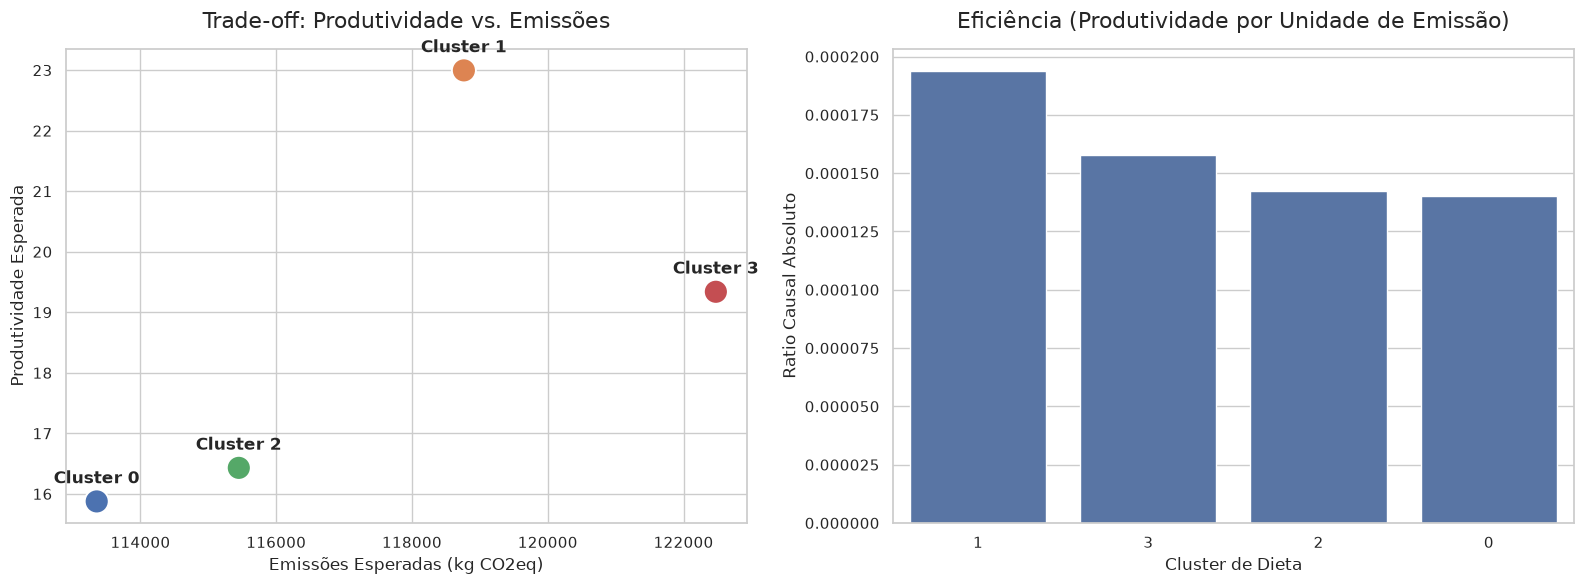

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transformando o dicionário bruto em um DataFrame do Pandas
df_results = pd.DataFrame(results).T
df_results.index.name = 'Cluster'
df_results.reset_index(inplace=True)

# Criando uma tabela bonita para impressão
print("--- RESUMO DO TRADE-OFF CAUSAL (CENÁRIOS ABSOLUTOS) ---")
display_df = df_results.copy()
display_df['Emissions'] = display_df['Emissions'].apply(lambda x: f"{x:,.2f} kg CO2eq")
display_df['Productivity'] = display_df['Productivity'].apply(lambda x: f"{x:,.2f}")
# Multiplicando o ratio por 10.000 para facilitar a leitura humana (ex: Litros por 10.000 kg CO2)
display_df['Ratio (x10k)'] = display_df['Ratio'].apply(lambda x: f"{x * 10000:.2f}") 
display_df = display_df.drop(columns=['Ratio'])
display(display_df)

# Plotagem dos Gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Dispersão (Trade-off de Pareto)
sns.scatterplot(
    data=df_results, x='Emissions', y='Productivity', 
    hue='Cluster', s=300, ax=axes[0], legend=False
)
# Adicionando os rótulos nos pontos
for i in range(df_results.shape[0]):
    axes[0].text(
        df_results['Emissions'][i], df_results['Productivity'][i] + 0.3,
        f"Cluster {df_results['Cluster'][i]}", 
        horizontalalignment='center', weight='bold', fontsize=12
    )
axes[0].set_title("Trade-off: Produtividade vs. Emissões", fontsize=16, pad=15)
axes[0].set_xlabel("Emissões Esperadas (kg CO2eq)", fontsize=12)
axes[0].set_ylabel("Produtividade Esperada", fontsize=12)

# Gráfico 2: Gráfico de Barras do Ratio (O Vencedor)
df_results_sorted = df_results.sort_values(by='Ratio', ascending=False)
sns.barplot(
    data=df_results_sorted, x='Cluster', y='Ratio', 
    ax=axes[1], order=df_results_sorted['Cluster']
)
axes[1].set_title("Eficiência (Produtividade por Unidade de Emissão)", fontsize=16, pad=15)
axes[1].set_xlabel("Cluster de Dieta", fontsize=12)
axes[1].set_ylabel("Ratio Causal Absoluto", fontsize=12)

plt.tight_layout()
plt.show()

Aqui, como uma forma de analisar mais criticamente os resultados obtidos, decidimos fazer uma análise da "força das setas" de nossa modelagem para o conjunto de dados específicos que estamos utilizando. Isso nos permite entender se os resultados obtidos são, de fato, confiáveis matematicamente. 

In [18]:
print("Avaliando o impacto direto (intrínseco) da Dieta na Produtividade e nas Emissões...\n")

# Força da seta para as Emissões de Metano
arrow_strengths_emissions = gcm.arrow_strength(
    causal_model,
    target_node='co2_enteric_fermentation'
)
dietary_strategy_to_emissions_arrow = ('Dietary_Strategy_Cluster', 'co2_enteric_fermentation')
emissions_strength = arrow_strengths_emissions.get(dietary_strategy_to_emissions_arrow, 0)

# Força da seta para a Produtividade
arrow_strengths_prod = gcm.arrow_strength(
    causal_model,
    target_node='Productivity'
)
dietary_strategy_to_prod_arrow = ('Dietary_Strategy_Cluster', 'Productivity')
prod_strength = arrow_strengths_prod.get(dietary_strategy_to_prod_arrow, 0)

# Exibindo os Resultados Diretos da Dieta
print(f"Força Causal DIRETA da Dieta nas Emissões: {emissions_strength:.4f}")
print(f"Força Causal DIRETA da Dieta na Produtividade: {prod_strength:.4f}\n")

# --- COMPARATIVO (Opcional, mas excelente para o artigo) ---
print("-> O que mais influencia as Emissões DIRETAMENTE?")
for (source, dest), strength in sorted(arrow_strengths_emissions.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   {source}: {strength:.4f}")

print("\n-> O que mais influencia a Produtividade DIRETAMENTE?")
for (source, dest), strength in sorted(arrow_strengths_prod.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   {source}: {strength:.4f}")

Avaliando o impacto direto (intrínseco) da Dieta na Produtividade e nas Emissões...

Força Causal DIRETA da Dieta nas Emissões: 0.0000
Força Causal DIRETA da Dieta na Produtividade: 8.5266

-> O que mais influencia as Emissões DIRETAMENTE?
   Lactating_Cows: 7880816507.2266
   Heifers: 323169135.0703
   Calves: 112594507.7812
   Dry_Cows: 75551919.2188
   Lactating_Cows_Weight: 0.0000

-> O que mais influencia a Produtividade DIRETAMENTE?
   Dietary_Strategy_Cluster: 8.5266


Como pode-se observar, a força da seta DIETA -> Emissões Entéricas é **NULA**, o que é preocupante e de certa forma tira confiabilidade dos resultados de trade-off obtidos. Fazendo uma análise mais apurada, descobrimos que isso se dá pela multicolinearidade perfeita para obtenção dos valores de Emissões. Esses valores de emissões foram calculados utilizando fórmulas determinísticas tendo como inputs os dados já representados no dataset. Dessa forma, há uma espécie de "*target-leakage*" no dataset específico empregado. 

## 5. Conclusões

Apesar dos resultados descritos acima para esse dataset, devido a natureza "calculada por fórmula" dos dados de emissão, ainda é possível aproveitar o código e o pipeline causal desenvolvido nos seguintes aspectos:
- A modelagem causal desenvolvida pode ser aproveitada para outras análises causais ou, ainda, como documentação importante de modelagem de dominio. 
- Todos os dados de Clustering de dietas obtidos podem ser aproveitados como insights analíticos da alimentação dos rebanhos representados nos datasets. 
- O código de Inferência Causal com DoWhy desenvolvido pode ser plenamente aproveitado para outros datasets onde não há, nos dados de emissões, valores obtidos por fórmulas diretas das variáveis de causa. Para datasets onde há emissões medidas por outros métodos, como medição direta observacional, o codigo é muito valioso para analisar o tradeoff entre produtividade e emissões com base em dietas. 